

# 🌍🤖 Metodología tradicional de aprendizaje automático aplicado a visión por computadora 🌿🏢
En este ejercicio, utilizaremos Haralick y LBP como técnicas de extracción de características para clasificar imágenes en 10 clases a partir del conjunto de datos EUROSAT 📡🛰️.

📂 Dataset: EUROSAT en Kaggle
📌 Clases disponibles:

🌾 Cultivo anual

🌳 Bosque

🍀 Vegetación herbácea

🛣️ Autopista

🏭 Industrial

🐄 Pastizal

🌿 Cultivo permanente

🏡 Residencial

🌊 Río

🌅 Mar/Lago


Como clasificador, emplearemos un Máquina de Vectores de Soporte (SVM) 🏆📊, un método robusto y eficiente en la clasificación de imágenes.

Este enfoque demuestra cómo la combinación de técnicas clásicas de visión por computadora y aprendizaje automático puede ser efectiva para la clasificación de imágenes satelitales 🚀🔍


#### USO OBLIGATORIO PARA CONECTAR CON GOOGLE DRIVE ⬇️

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##### Descarga del dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")
print("Path to dataset files:", path)

###### Si usáis Google Colab y Drive para el trabajo:

In [5]:
%cd /content/drive/MyDrive/UNIR

[Errno 2] No such file or directory: '/content/drive/MyDrive/UNIR'
/content


In [ ]:
 # Selecciona el working directory (directorio desde donde se va a trabajar)
import shutil
destino_drive = '.' # Aquí va vuestro path dentro de Google Drive.
shutil.move(path, destino_drive)

In [2]:
# path al dataset
data_dir = '/content/drive/MyDrive/UNIR/6/EuroSAT'

                                              image_path label  \
3699                             Highway/Highway_158.jpg     3   
11101                            Pasture/Pasture_757.jpg     5   
2771                              Forest/Forest_2867.jpg     1   
18573  HerbaceousVegetation/HerbaceousVegetation_837.jpg     2   
14175                            Pasture/Pasture_826.jpg     5   

                   category  
3699                Highway  
11101               Pasture  
2771                 Forest  
18573  HerbaceousVegetation  
14175               Pasture  


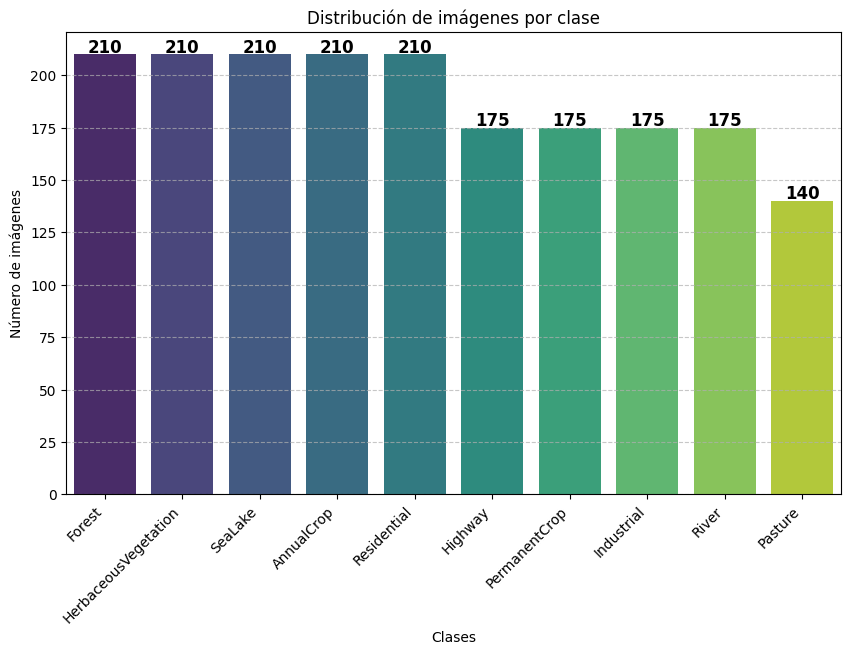

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Cargar el dataset desde el archivo csv, está dentro de la carpeta EuroSAT. Solo cargamos este archivo para limitar el tamaño del dataset.
df = pd.read_csv(f"{data_dir}/train.csv", sep=",", header=None, names=["image_path", "label", "category"], dtype=str)

df = df.iloc[1:].reset_index(drop=True) # Eliminar la primera fila, los headers por defecto.

df.dropna(inplace=True) # Eliminar valores nan
df, _ = train_test_split(df, test_size=0.9, stratify=df["category"], random_state=42) # Modificar el test_size para aumentar el tamaño del dataset ahora usa el 10%
# Mostrar las primeras filas
print(df.head())

# Contar la cantidad de imágenes por clase
class_counts = df["category"].value_counts()

# Configurar el gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette="viridis", legend=False)

# Agregar los valores en la parte superior de cada barra
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2,  # Posición en X
            p.get_height() + 1,             # Posición en Y (ligeramente arriba de la barra)
            int(p.get_height()),            # Valor a mostrar
            ha="center", fontsize=12, fontweight="bold")
# Personalizar el gráfico
plt.xticks(rotation=45, ha="right")
plt.xlabel("Clases")
plt.ylabel("Número de imágenes")
plt.title("Distribución de imágenes por clase")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Mostrar la gráfica
plt.show()



# Haralick y Local Pattern Binary (LBP)

##📷 Haralick Features
Las características de Haralick son un conjunto de 13 descriptores (14 pero el último se considera inestable y no está incluido en Mahotas) de textura extraídos de la Matriz de Co-ocurrencia de Niveles de Gris (GLCM). Esta matriz describe la relación espacial entre los píxeles en una imagen y permite capturar información sobre su textura.

Las 13 características de Haralick son:

1. Energía (Angular Second Moment - ASM) ⚡: Mide la uniformidad de la distribución de la textura. Valores altos indican una textura uniforme.

2. Contraste 🎭: Evalúa la diferencia entre valores de gris en la imagen. Valores altos indican más variabilidad en la textura.

3. Correlación 🔗: Indica la similitud entre los píxeles adyacentes.

4. Varianza 📊: Mide la dispersión de los valores de la GLCM con respecto a la media.

5. Inverso de la diferencia de momento (IDM) ⚖️: También llamado "homogeneidad", mide la suavidad de la textura.

6. Suma de la media ➕: Mide la media de las sumas de la GLCM.

7. Suma de la varianza 🎲: Mide la dispersión en la suma de la GLCM.

8. Suma de la entropía 🔀: Evalúa el nivel de desorden en la textura.

9. Entropía 📉: Mide la cantidad de información contenida en la imagen, donde valores altos indican más aleatoriedad.

10. Diferencia de varianza ➖📊: Evalúa la variabilidad en la diferencia de valores en la GLCM.

11. Diferencia de entropía 🔽: Mide el desorden en la diferencia de valores en la GLCM.

12. Medidas de correlación 1 y 2 🔍 (son la 12 y 13): Miden la relación entre píxeles utilizando ecuaciones específicas para capturar patrones de dependencia.

##🔳 Local Binary Pattern (LBP)
El LBP es un método de extracción de características de textura basado en la comparación local de píxeles. Funciona de la siguiente manera:

Cada píxel en la imagen se compara con sus vecinos en un radio definido.
Se genera un patrón binario, asignando un 1 si el píxel vecino es mayor o igual al píxel central, y 0 en caso contrario.

###🛠 1. Radio (R)
El radio (R) define la distancia entre el píxel central y los píxeles vecinos utilizados para calcular el LBP.

📌 Ejemplo de radios comunes:

R = 1: Vecinos en una distancia de 1 píxel (patrón más local).
R = 2: Vecinos en una distancia de 2 píxeles (captura texturas más globales).
R = 3: Vecinos aún más lejanos, útil para texturas más amplias.

Un radio mayor permite capturar información más global de la textura, pero también puede perder detalles finos.

### 🔢 2. Número de Puntos (P)
El número de puntos (P) indica cuántos vecinos se seleccionan en la circunferencia de radio R.

📌 Ejemplo de números de puntos comunes:

P = 8: Se toman 8 píxeles vecinos en una circunferencia.
P = 16: Se toman 16 píxeles, capturando más detalles.

In [5]:
!pip3 install mahotas

In [6]:
import os
import cv2
import numpy as np
import pandas as pd
import mahotas  # Para características de Haralick
from skimage.feature import local_binary_pattern  # Para LBP
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Función para extraer características Haralick
def extract_haralick_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    haralick = mahotas.features.haralick(gray).mean(axis=0)
    return haralick

# Función para extraer características LBP
def extract_lbp_features(image):
    # Parámetros de LBP
    radius = 3
    n_points = 8 * radius
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    hist = hist.astype('float')
    hist /= (hist.sum() + 1e-7)
    return hist

#### Celda para probar la distribución de vecinos en LBP y como afecta:

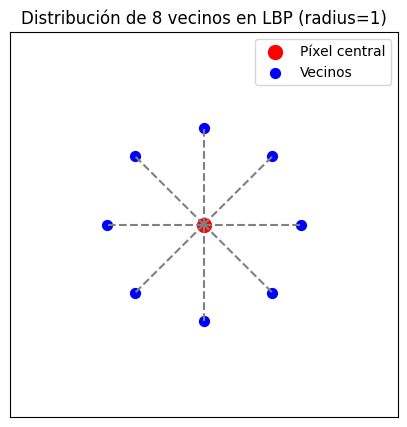

In [7]:
# Se restableció el estado, por lo que necesito redefinir las librerías y volver a ejecutar el código

import numpy as np
import matplotlib.pyplot as plt

# Parámetros de LBP
radius = 1
n_points = 8 * radius

# Coordenadas de los puntos en el círculo
angles = np.linspace(0, 2 * np.pi, n_points, endpoint=False)
x_points = radius * np.cos(angles)
y_points = radius * np.sin(angles)

# Graficar el píxel central y los puntos vecinos
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(0, 0, color='red', label="Píxel central", s=100)  # Píxel central
ax.scatter(x_points, y_points, color='blue', label="Vecinos", s=50)  # Puntos vecinos

# Conectar el píxel central con sus vecinos
for x, y in zip(x_points, y_points):
    ax.plot([0, x], [0, y], 'gray', linestyle="dashed")

# Configurar la gráfica
ax.set_xlim(-radius - 1, radius + 1)
ax.set_ylim(-radius - 1, radius + 1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"Distribución de {n_points} vecinos en LBP (radius={radius})")
ax.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


Explicación de los parámetros:
radius = 3

Define la distancia desde el píxel central hasta los píxeles vecinos que se usarán para calcular el LBP.
Un radius = 3 significa que los píxeles vecinos estarán en un círculo de radio 3 alrededor del píxel central.
n_points = 8 * radius

Indica cuántos puntos vecinos se toman en cuenta en la circularidad de LBP.
Se usa la relación 8 * radius porque LBP generalmente utiliza 8 vecinos por cada unidad de radio.
En este caso, n_points = 8 * 3 = 24, lo que significa que tomaremos 24 puntos distribuidos alrededor del píxel central.
Representación gráfica de LBP con estos parámetros:
Si radius = 1, los vecinos estarían en una cuadrícula de 3x3 alrededor del píxel central.
Si radius = 3, los vecinos se expanden en un círculo más grande, aumentando el nivel de detalle en la textura.

Esto ayuda a capturar mejor las características de la textura en imágenes, especialmente en clasificación de imágenes y reconocimiento de patrones.










In [10]:
# Recorrer imágenes del CSV y extraer características
features, labels = [], []

for i, filename in enumerate(df['image_path']):
    print(f"{i}/{len(df['image_path'])}")
    image_path = os.path.join(data_dir, filename)
    if os.path.exists(image_path):
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Extraer características
        haralick_features = extract_haralick_features(image)
        lbp_features = extract_lbp_features(image)

        # Concatenar características
        feature_vector = np.hstack([haralick_features, lbp_features])

        # Guardar en listas
        features.append(feature_vector)
        labels.append(df['label'].iloc[i])

# Convertir a arrays de NumPy
features = np.array(features)
labels = np.array(labels)

# Entrenamiento y evaluación del modelo

In [11]:
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

In [12]:
# Normalización (es opcional)
from sklearn.preprocessing import StandardScaler

# Estandarizar características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

svm = SVC(kernel='linear', C=1, random_state=42)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
model = svm
classification_report = classification_report(y_test, y_pred)
print(f"Classification report\n: {classification_report}")

Classification report
:               precision    recall  f1-score   support

           0       0.76      0.86      0.81        36
           1       0.98      1.00      0.99        42
           2       0.69      0.81      0.75        42
           3       0.50      0.51      0.51        41
           4       0.82      0.91      0.86        35
           5       0.91      0.77      0.83        26
           6       0.69      0.61      0.65        36
           7       0.90      0.90      0.90        30
           8       0.89      0.67      0.77        49
           9       0.93      0.98      0.95        41

    accuracy                           0.80       378
   macro avg       0.81      0.80      0.80       378
weighted avg       0.80      0.80      0.80       378



# Matriz de confusión

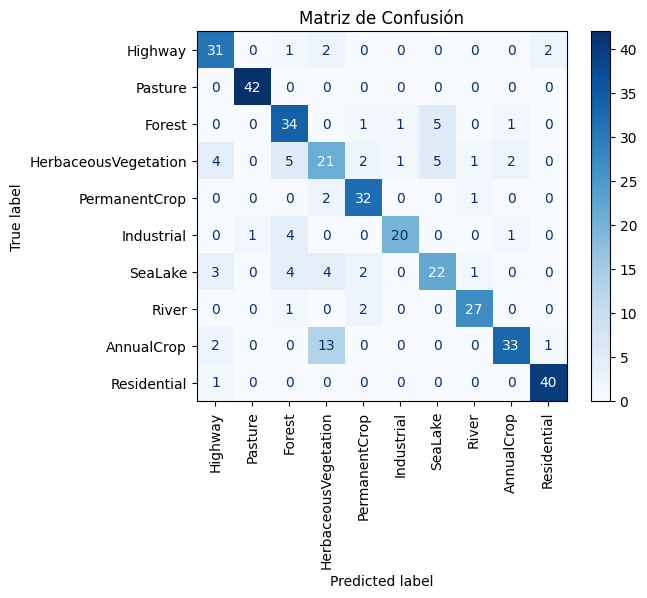

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Suponiendo que tienes las etiquetas reales y predicciones del modelo
y_true = y_test  # Etiquetas reales
y_pred = model.predict(X_test)  # Predicciones del modelo
class_names = df["category"].unique()

# Crear la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)

# Rotar etiquetas del eje X
plt.xticks(rotation=90)

plt.title("Matriz de Confusión")
plt.show()


### Curva de aprendizaje

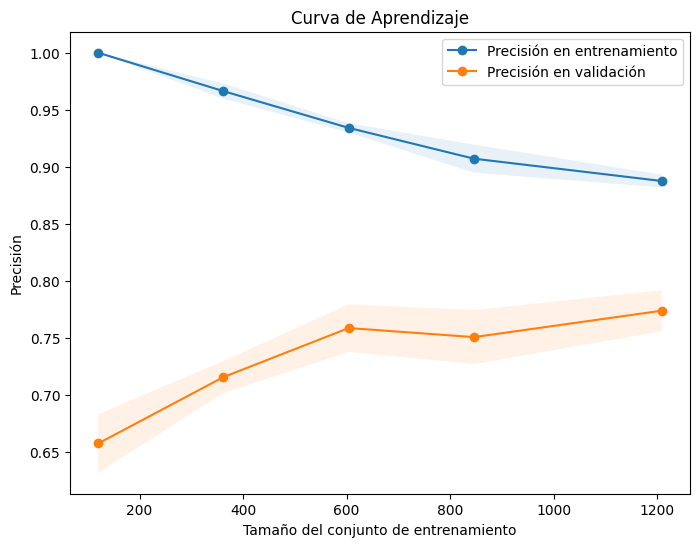

In [15]:
from sklearn.model_selection import learning_curve

# Definir las fracciones de datos de entrenamiento
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=[0.1, 0.3, 0.5, 0.7, 1.0])

# Calcular las medias y desviaciones estándar
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

# Graficar la curva de aprendizaje
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', label="Precisión en entrenamiento")
plt.plot(train_sizes, test_mean, 'o-', label="Precisión en validación")

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)

plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Precisión")
plt.title("Curva de Aprendizaje")
plt.legend()
plt.show()


# Redes convolucionales (CNNs)

Las Redes Neuronales Convolucionales (CNNs, por sus siglas en inglés) son un tipo de red neuronal diseñada para procesar datos con estructura de rejilla, como imágenes. Son ampliamente utilizadas en visión por computadora y tareas como reconocimiento de imágenes, clasificación y segmentación.

Componentes clave de una CNN:
Capas Convolucionales: Aplican filtros (kernels) a la imagen de entrada para extraer características como bordes, texturas y patrones más complejos en capas más profundas.

Función de Activación: Generalmente se usa ReLU (Rectified Linear Unit) para introducir no linealidad y mejorar el aprendizaje.

Capas de Pooling: Reducen la dimensionalidad de la imagen manteniendo las características más importantes (ejemplo: Max Pooling o Average Pooling).
Capas Completamente Conectadas (FC): Transforman las características extraídas en la salida deseada, como una clasificación. (Capas Dense)

Backpropagation y Optimización: Se utiliza el algoritmo de retropropagación junto con optimizadores como Adam o SGD para ajustar los pesos de la red.

En TensorFlow/Keras, la capa Conv2D se usa para aplicar una convolución a una imagen de entrada. Los parámetros más relevantes son:

1. Filtros (filters)
Especifica el número de filtros o kernels que se aplicarán a la imagen.
Más filtros permiten capturar más características (bordes, texturas, patrones).
Ejemplo: filters=32 aplica 32 filtros diferentes.
2. Tamaño del kernel (kernel_size)
Define el tamaño de la ventana deslizante (filtro).
Comúnmente se usan tamaños como (3,3) o (5,5).
Debe ser más pequeño que la imagen de entrada.
3. Paso o desplazamiento (strides)
Indica cuánto se mueve el filtro en cada paso horizontal y vertical.
Valor por defecto: (1,1), lo que significa que se mueve de píxel en píxel.
Un stride mayor reduce el tamaño de salida, similar a un pooling.
4. Tipo de padding (padding)
Determina cómo se manejan los bordes de la imagen:
"valid": No agrega padding (reduce el tamaño de salida).
"same": Agrega padding para mantener el tamaño de salida igual al de entrada.
5. Función de activación (activation)
Introduce no linealidad en la capa.
Comúnmente se usa ReLU (activation="relu") para mejorar el entrenamiento.

In [16]:
# Importación de librerías necesarias
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [17]:
images = []
labels = []

# Recorrer imágenes del CSV y cargarlas
for i, filename in enumerate(df['image_path']):
    image_path = os.path.join(data_dir, filename)
    if os.path.exists(image_path):
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convertir de BGR a RGB
        image = cv2.resize(image, (64, 64))  # Redimensionar la imagen a 64x64 píxeles

        # Añadir imagen y etiqueta
        images.append(image)
        labels.append(int(df['label'].iloc[i]))

In [18]:
# Convertir las listas a arrays de NumPy
images = np.array(images)
labels = np.array(labels)

# Normalizar las imágenes (valores entre 0 y 1)
images = images / 255.0

# Codificar las etiquetas (si son categóricas)
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

# Convertir las etiquetas a one-hot encoding
labels = to_categorical(labels)

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

In [19]:
# Crear la CNN
model = Sequential()

# Capa convolucional 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(MaxPooling2D((2, 2)))

# Capa convolucional 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Capa convolucional 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Aplanar las características de la última capa convolucional
model.add(Flatten())

# Capa densa
model.add(Dense(128, activation='relu'))

# Capa de salida (número de clases, con activación softmax)
model.add(Dense(labels.shape[1], activation='softmax'))

# Compilar el modelo
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
# Entrenar el modelo
model.fit(X_train, y_train, epochs=1, batch_size=32, validation_data=(X_test, y_test))

# Evaluar el modelo en el conjunto de prueba
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')

# Realizar predicciones
y_pred = model.predict(X_test)

# Convertir las predicciones a etiquetas
y_pred_labels = np.argmax(y_pred, axis=1)

# Convertir las etiquetas verdaderas a etiquetas originales
y_test_labels = np.argmax(y_test, axis=1)

# Evaluar el rendimiento
from sklearn.metrics import classification_report, accuracy_score
print('Accuracy:', accuracy_score(y_test_labels, y_pred_labels))
print('Classification Report:')
print(classification_report(y_test_labels, y_pred_labels, zero_division=1))

48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 346ms/step - accuracy: 0.2784 - loss: 1.8025 - val_accuracy: 0.3624 - val_loss: 1.5971
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3503 - loss: 1.6106
Test accuracy: 0.36243385076522827
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
Accuracy: 0.36243386243386244
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.36      0.48        36
           1       1.00      0.00      0.00        42
           2       0.08      0.02      0.04        42
           3       0.26      0.24      0.25        41
           4       0.49      0.83      0.62        35
           5       0.21      0.12      0.15        26
           6       0.34      0.50      0.40        36
           7       0.50      0.27      0.35        30
           8       0.37      0.43      0.40        49
           9       0.31      0.83      0.45        41

    accuracy                           0.36       378
   macro avg       0.43      0